<a href="https://colab.research.google.com/github/hariharan-vs/24ADI003---24BAD030/blob/main/week_6(scenario_1%2C2%2C3%2C4%2C5)_24BAD030_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hariharan V S - 24BAD030
Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


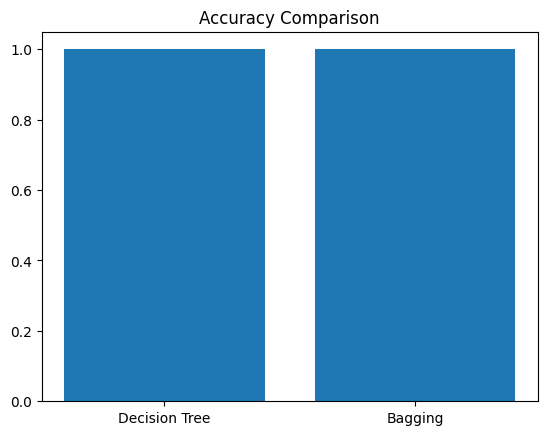

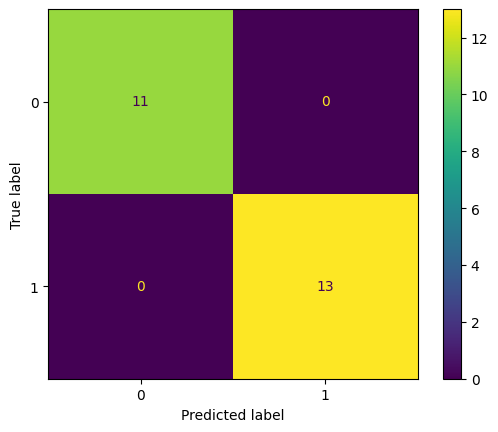

In [8]:
print("Hariharan V S - 24BAD030")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.show()

Hariharan V S - 24BAD030
AdaBoost: 1.0
Gradient Boosting: 1.0


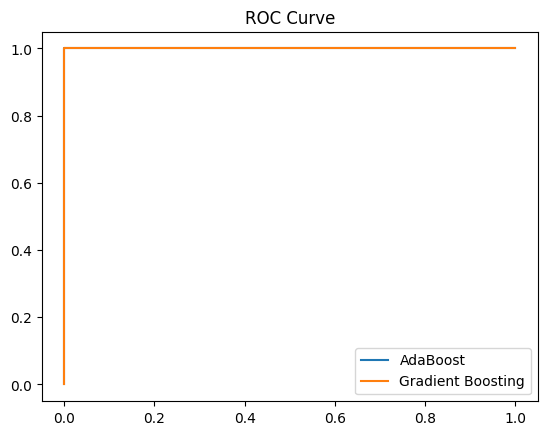

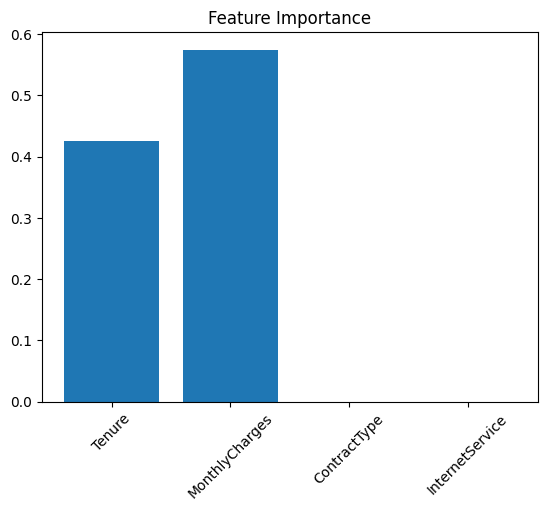

In [20]:
print("Hariharan V S - 24BAD030")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("churn_boosting.csv")

df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

y_pred_ada = ada.predict_proba(X_test)[:,1]
y_pred_gb = gb.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, y_pred_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_gb)

print("AdaBoost:", ada.score(X_test,y_test))
print("Gradient Boosting:", gb.score(X_test,y_test))

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.legend()
plt.title("ROC Curve")
plt.show()

plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

Hariharan V S - 24BAD030


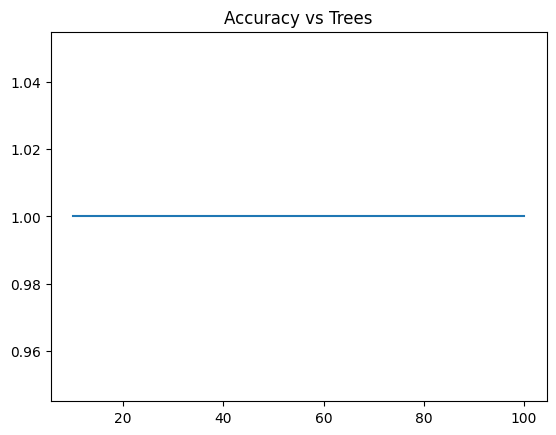

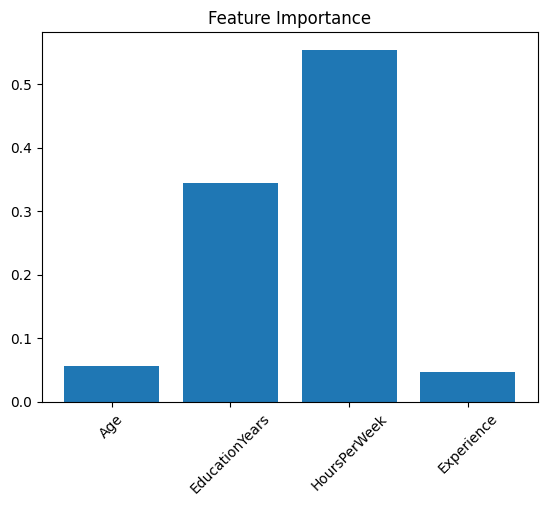

In [10]:
print("Hariharan V S - 24BAD030")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("income_random_forest.csv")

df = df.apply(LabelEncoder().fit_transform)

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scores = []
trees = [10, 50, 100]

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.plot(trees, scores)
plt.title("Accuracy vs Trees")
plt.show()

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

Hariharan V S - 24BAD030
Logistic Regression : 0.8333333333333334
SVM : 0.9583333333333334
Decision Tree : 0.9583333333333334
Stacking : 0.9583333333333334


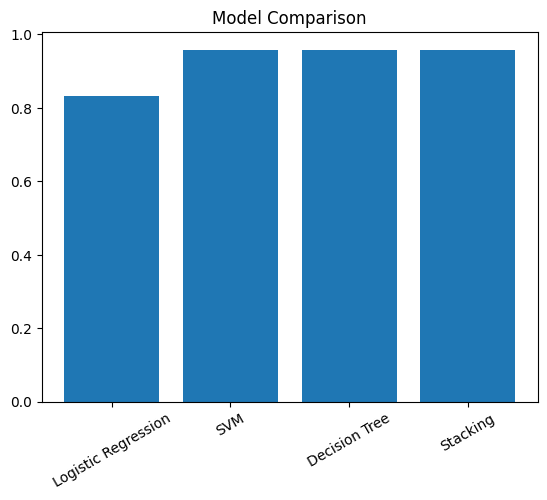

In [21]:
print("Hariharan V S - 24BAD030")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("heart_stacking.csv")


df = df.apply(LabelEncoder().fit_transform)


X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()


lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)


estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)


scores = {
    "Logistic Regression": lr.score(X_test, y_test),
    "SVM": svm.score(X_test, y_test),
    "Decision Tree": dt.score(X_test, y_test),
    "Stacking": stack.score(X_test, y_test)
}


for model, score in scores.items():
    print(model, ":", score)


plt.bar(scores.keys(), scores.values())
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

Hariharan V S - 24BAD030
Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


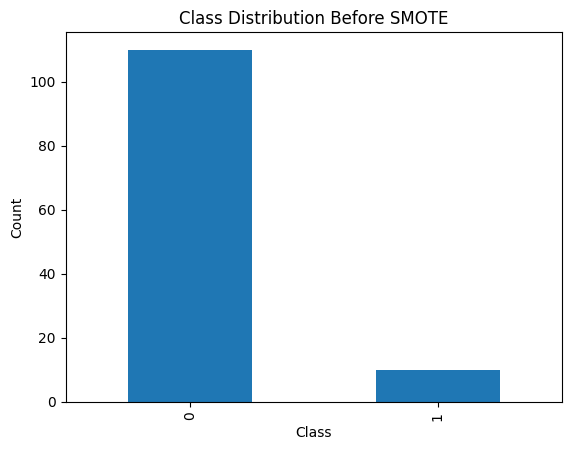

Accuracy Before SMOTE: 0.9166666666666666
After SMOTE:
 Fraud
0    110
1    110
Name: count, dtype: int64


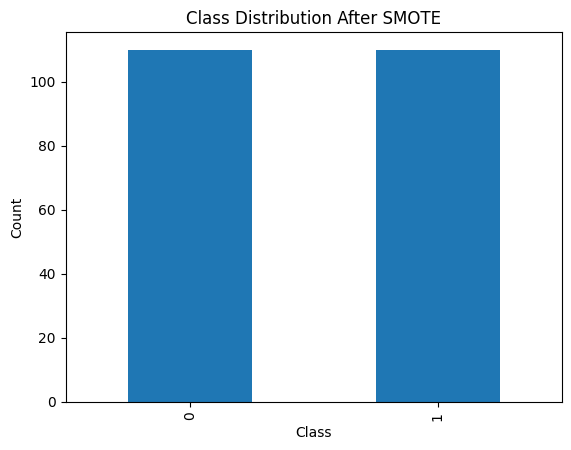

Accuracy After SMOTE: 0.8636363636363636


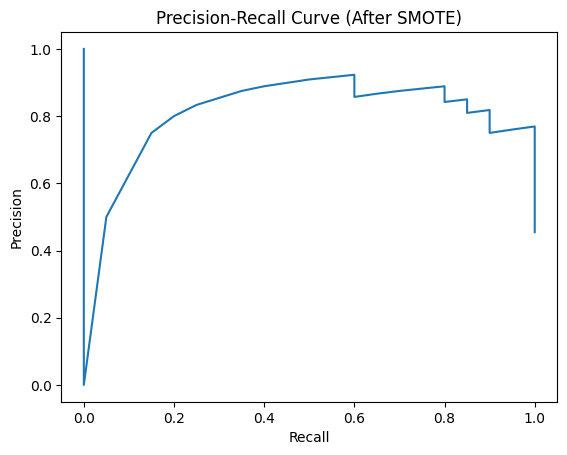

In [22]:
print("Hariharan V S - 24BAD030")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, accuracy_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv("fraud_smote.csv")

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

print("Before SMOTE:\n", y.value_counts())


y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train_b, y_train_b)

y_pred_before = model_before.predict(X_test_b)
acc_before = accuracy_score(y_test_b, y_pred_before)

print("Accuracy Before SMOTE:", acc_before)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train, y_train)

y_pred_after = model_after.predict(X_test)
acc_after = accuracy_score(y_test, y_pred_after)

print("Accuracy After SMOTE:", acc_after)

y_scores = model_after.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve (After SMOTE)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()